对恒生指数期货进行回测

### 读取数据库数据

In [117]:
from sysdata.sim.db_futures_sim_data import dbFuturesSimData
data=dbFuturesSimData()
data


dbFuturesSimData object with 15 instruments

### 看看有什么工具

In [118]:
data.get_instrument_list()

['CHFJPY',
 'SP500_micro',
 'US20',
 'CORN',
 'FTSECHINAA',
 'V2X',
 'FTSECHINAH',
 'NASDAQ',
 'GOLD',
 'SP500',
 'BITCOIN',
 'HANGTECH',
 'EUROSTX',
 'US10',
 'HANG']

In [119]:
data.get_instrument_meta_data("HANG")

futuresInstrumentWithMetaData(instrument=HANG, meta_data={'Description': 'Hong Kong equity index Hang Seng', 'Pointsize': np.float64(50.0), 'Currency': 'HKD', 'AssetClass': 'Equity', 'PerBlock': np.float64(30.0), 'Percentage': np.float64(0.0), 'PerTrade': np.int64(0), 'Region': 'ASIA'})

In [120]:
data.get_raw_price("HANG").tail(10)

index
2025-03-28 10:00:00    23359.0
2025-03-28 11:00:00    23406.0
2025-03-28 12:00:00    23380.0
2025-03-28 13:00:00    23371.0
2025-03-28 14:00:00    23313.0
2025-03-28 15:00:00    23311.0
2025-03-28 16:00:00    23276.0
2025-03-28 17:00:00    23265.0
2025-03-28 18:00:00    23284.0
2025-03-31 05:00:00    23284.0
Name: price, dtype: float64

In [121]:
data.keys()
data['HANGTECH']

index
2020-12-21 02:00:00    8619.0
2020-12-21 03:00:00    8612.0
2020-12-21 05:00:00    8599.0
2020-12-21 06:00:00    8579.0
2020-12-21 07:00:00    8546.0
                        ...  
2025-03-28 15:00:00    5447.0
2025-03-28 16:00:00    5435.0
2025-03-28 17:00:00    5431.0
2025-03-28 18:00:00    5439.0
2025-03-31 05:00:00    5439.0
Name: price, Length: 17911, dtype: float64

In [122]:
data.get_instrument_raw_carry_data("HANG")


,PRICE,CARRY,PRICE_CONTRACT,CARRY_CONTRACT
index,,,,
2019-07-22 02:00:00,28494.0,28425.0,20190800,20190900
2019-07-22 03:00:00,28507.0,28439.0,20190800,20190900
2019-07-22 05:00:00,28337.0,28259.0,20190800,20190900
2019-07-22 06:00:00,28408.0,28335.0,20190800,20190900
2019-07-22 07:00:00,28302.0,28230.0,20190800,20190900
...,...,...,...,...
2025-03-28 15:00:00,23311.0,NaN,20250400,20250500
2025-03-28 16:00:00,23276.0,NaN,20250400,20250500
2025-03-28 17:00:00,23265.0,NaN,20250400,20250500


In [123]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc

def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds Lfast, Lslow and vol_lookback

    """
    ## price: This is the stitched price series
    ## We can't use the price of the contract we're trading, or the volatility will be jumpy
    ## And we'll miss out on the rolldown. See https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html

    price = price.resample("1B").last()
    if Lslow is None:
        Lslow = 4 * Lfast

    ## We don't need to calculate the decay parameter, just use the span directly

    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol

In [140]:
data.db_fx_prices_data.get_fx_prices('HKDUSD')

2025-03-30 19:18:10 WARNING dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'HKDUSD'} Currency HKDUSD is missing from list of FX data


fxPrices([], dtype: object)

In [160]:
from sysdata.csv.csv_spot_fx import csvFxPricesData
csv_fx_prices = csvFxPricesData()
list_of_ccy_codes = csv_fx_prices.get_list_of_fxcodes()

db_fx_price_data = data.db_fx_prices_data

for currency_code in list_of_ccy_codes:
    fx_prices = csv_fx_prices.get_fx_prices(currency_code)
    print(currency_code)
    db_fx_price_data.add_fx_prices(
        code=currency_code, fx_price_data=fx_prices, ignore_duplication=True
    )

SGDUSD
2025-03-30 23:19:11 DEBUG dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'SGDUSD'} Wrote 9400 lines of prices for SGDUSD to parquetFxPricesData
2025-03-30 23:19:11 INFO dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'SGDUSD'} Added fx data for code SGDUSD
HKDUSD
2025-03-30 23:19:11 DEBUG dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'HKDUSD'} Wrote 8856 lines of prices for HKDUSD to parquetFxPricesData
2025-03-30 23:19:11 INFO dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'HKDUSD'} Added fx data for code HKDUSD
EURUSD
2025-03-30 23:19:11 DEBUG dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'EURUSD'} Wrote 6377 lines of prices for EURUSD to parquetFxPricesData
2025-03-30 23:19:11 INFO dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'EURUSD'} Added fx data for code EURUSD
CADUSD
2025-03-30 23:19:11 DEBUG dbFuturesSimData {'component': 'pa

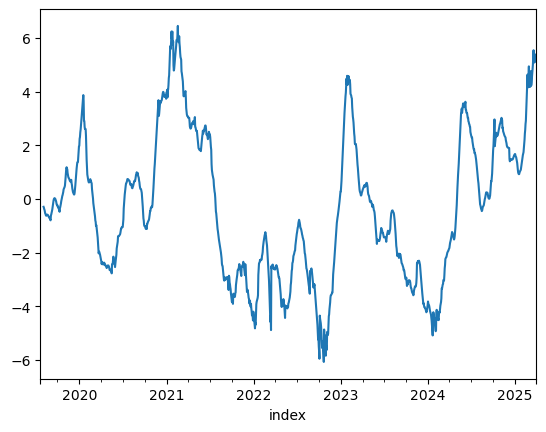

In [148]:
instrument_code='HANG'
price=data.daily_prices(instrument_code)
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

from matplotlib.pyplot import show
ewmac.plot()
show()

In [149]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price=price)
account.percent.stats()

[[('min', '-2.778'),
  ('max', '2.253'),
  ('median', '0'),
  ('mean', '-0.001133'),
  ('std', '0.3026'),
  ('skew', '-0.6829'),
  ('ann_mean', '-0.2901'),
  ('ann_std', '4.842'),
  ('sharpe', '-0.05992'),
  ('sortino', '-0.06894'),
  ('avg_drawdown', '-4.974'),
  ('time_in_drawdown', '0.9818'),
  ('calmar', '-0.02699'),
  ('avg_return_to_drawdown', '-0.05834'),
  ('avg_loss', '-0.1939'),
  ('avg_gain', '0.1862'),
  ('gaintolossratio', '0.96'),
  ('profitfactor', '0.9876'),
  ('hitrate', '0.5071'),
  ('t_stat', '-0.1444'),
  ('p_value', '0.8852')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

annual mean for gross returns -0.2901430056142124


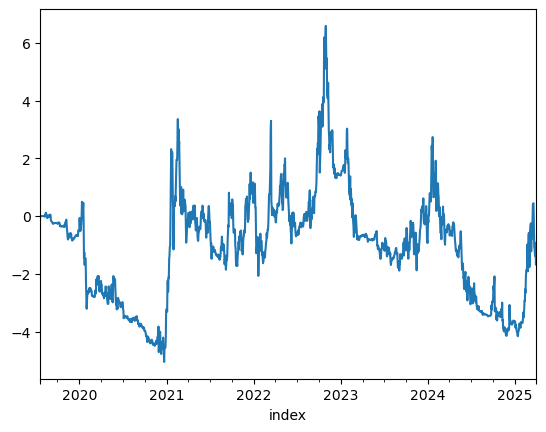

In [150]:
import syscore.pandas.strategy_functions

account.sharpe()  ## get the Sharpe Ratio (annualised), and any other statistic which is in the stats list
account.curve().plot()  ## plot the cumulative account curve (equivalent to account.cumsum().plot() inicidentally)
account.percent  ## gives a % curve
#syscore.pandas.strategy_functions.drawdown().plot()  ## see the drawdowns as a percentage
account.weekly  ## weekly returns (also daily [default], monthly, annual)
print("annual mean for gross returns",account.gross.ann_mean())  ## annual mean for gross returns, also costs (there are none in this simple example)

In [151]:
from systems.provided.rules.ewmac import ewmac_forecast_with_defaults as ewmac
from systems.forecasting import Rules
my_rules = Rules(dict(ewmac=ewmac))
my_rules.trading_rules()

{'ewmac': TradingRule; function: <function ewmac_forecast_with_defaults at 0x16579b560>, data: data.daily_prices (args: {}) and other_args: }

In [128]:

from systems.trading_rules import TradingRule

ewmac_rule = TradingRule(ewmac)
my_rules = Rules(dict(ewmac=ewmac_rule))
ewmac_rule

TradingRule; function: <function ewmac_forecast_with_defaults at 0x16579b560>, data: data.daily_prices (args: {}) and other_args: 

In [152]:
from systems.basesystem import System
from systems.trading_rules import TradingRule

ewmac_8 = TradingRule(ewmac, [], dict(Lfast=8, Lslow=32))
ewmac_32 = TradingRule(ewmac, [], dict(Lfast=32, Lslow=128))
my_rules = Rules(dict(ewmac8=ewmac_8, ewmac32=ewmac_32))
my_rules.trading_rules()['ewmac32']

my_system = System([my_rules], data)
my_system.rules.get_raw_forecast("HANG", "ewmac32").tail(5)
# my_system.rules.get_raw_forecast("HANG", "ewmac").tail(5)

2025-03-30 19:24:46 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-03-30 19:24:46 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-03-30 19:24:46 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-03-30 19:24:46 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-03-30 19:24:46 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forecast HANG for ewmac32


index
2025-03-25    1.403183
2025-03-26    1.426178
2025-03-27    1.453798
2025-03-28    1.471522
2025-03-31    1.489515
Freq: B, Name: price, dtype: float64

In [153]:
from sysdata.config.configdata import Config
my_config=Config()
my_config

Config with elements: 

In [155]:
empty_rules=Rules()
my_config.trading_rules=dict(ewmac8=ewmac_8, ewmac32=ewmac_32)
my_system=System([empty_rules], data, my_config)
print(my_system.rules.get_raw_forecast("HANG", "ewmac8"))

2025-03-30 19:24:57 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-03-30 19:24:57 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-03-30 19:24:57 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-03-30 19:24:57 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-03-30 19:24:57 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forecast HANG for ewmac8
index
2019-07-22         NaN
2019-07-23         NaN
2019-07-24         NaN
2019-07-25         NaN
2019-07-26         NaN
                ...   
2025-03-25    0.464986
2025-03-26    0.395686
2025-03-27    0.377161
2025-03-28    0.298036
2025-03-31    0.234839
Freq: B, Name: price, Length: 1486, dtype: float64


In [156]:
from systems.forecast_scale_cap import ForecastScaleCap


## By default we pool estimates across instruments. It's worth telling the system what instruments we want to use:
#
my_config.instruments=["HANG", "US10", "CORN", "SP500"]

## this parameter ensures we estimate:
my_config.use_forecast_scale_estimates=True

fcs=ForecastScaleCap()
my_system = System([fcs, my_rules], data, my_config)
print(my_system.forecastScaleCap.get_forecast_scalar("HANG", "ewmac32").tail(5))

2025-03-30 19:25:00 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-03-30 19:25:00 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-03-30 19:25:00 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-03-30 19:25:00 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-03-30 19:25:00 DEBUG base_system {'stage': 'forecastScaleCap'} Getting cross sectional forecasts for scalar calculation for ewmac32 over CORN, HANG, SP500, US10
2025-03-30 19:25:00 DEBUG base_system {'stage': 'rules', 'instrument_code': 'CORN'} Calculating raw forecast CORN for ewmac32
2025-03-30 19:25:00 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forecast HANG for ewmac32
2025-03-30 19:25:00 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for e

In [157]:
my_config.forecast_scalars=dict(ewmac8=5.3, ewmac32=2.65)

## this parameter ensures we don't estimate:
my_config.use_forecast_scale_estimates=False

my_system=System([fcs, empty_rules], data, my_config)

print(my_system.forecastScaleCap.get_forecast_scalar("HANG", "ewmac32"))
2.65 # now a single float value

my_system.forecastScaleCap.get_capped_forecast("HANG", "ewmac32")

2025-03-30 19:25:04 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-03-30 19:25:04 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-03-30 19:25:04 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-03-30 19:25:04 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-03-30 19:25:04 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forecast HANG for ewmac32
index
2019-07-22    2.65
2019-07-23    2.65
2019-07-24    2.65
2019-07-25    2.65
2019-07-26    2.65
              ... 
2025-03-25    2.65
2025-03-26    2.65
2025-03-27    2.65
2025-03-28    2.65
2025-03-31    2.65
Freq: B, Length: 1486, dtype: float64
2025-03-30 19:25:04 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'HANG'} Calculating capped forecast for HANG ewmac32


index
2019-07-22         NaN
2019-07-23         NaN
2019-07-24         NaN
2019-07-25         NaN
2019-07-26         NaN
                ...   
2025-03-25    3.718434
2025-03-26    3.779372
2025-03-27    3.852564
2025-03-28    3.899533
2025-03-31    3.947215
Freq: B, Length: 1486, dtype: float64

In [158]:
from systems.forecast_combine import ForecastCombine

combiner = ForecastCombine()
my_system = System([fcs, empty_rules, combiner], data, my_config)
my_system.combForecast.get_forecast_weights("US10").tail(5)
my_system.combForecast.get_forecast_diversification_multiplier("US10").tail(5)


2025-03-30 19:25:11 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-03-30 19:25:11 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-03-30 19:25:11 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-03-30 19:25:11 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-03-30 19:25:11 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'US10'} Calculating forecast weights for US10
2025-03-30 19:25:11 WARNING base_system {'stage': 'combForecast', 'instrument_code': 'US10'} WARNING: No forecast weights  - using equal weights of 0.500 over all 2 trading rules in system
2025-03-30 19:25:11 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'US10'} Calculating capped forecast for US10 ewmac32
2025-03-30 19:25:11 DEBUG base_system {'stage': 'rules', 'instrument_code': 'US10

/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month


index
2024-12-13    1.0
2024-12-16    1.0
2024-12-17    1.0
2024-12-18    1.0
2024-12-19    1.0
Freq: B, dtype: float64

In [159]:
from systems.rawdata import RawData
from systems.positionsizing import PositionSizing
from systems.accounts.accounts_stage import Account
combiner = ForecastCombine()
raw_data = RawData()
position_size = PositionSizing()
my_account = Account()

## let's use naive markowitz to get more interesting results...
my_config.forecast_weight_estimate = dict(method="one_period")
my_config.use_forecast_weight_estimates = True
my_config.use_forecast_div_mult_estimates = True

combiner = ForecastCombine()
my_system = System([my_account, fcs, my_rules, combiner, position_size, raw_data], data, my_config)

print(my_system.combForecast.get_forecast_weights("HANG").tail(5))
print(my_system.combForecast.get_forecast_diversification_multiplier("HANG").tail(5))


2025-03-30 19:25:18 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-03-30 19:25:18 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-03-30 19:25:18 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-03-30 19:25:18 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-03-30 19:25:18 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'HANG'} Calculating forecast weights for HANG
2025-03-30 19:25:18 INFO base_system {'stage': 'combForecast', 'instrument_code': 'HANG'} Calculating raw forecast weights for HANG
2025-03-30 19:25:18 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'CORN'} Calculating capped forecast for CORN ewmac32
2025-03-30 19:25:18 DEBUG base_system {'stage': 'rules', 'instrument_code': 'CORN'} Calculating raw forecast CORN for ewmac32
2025-03-30 1

In [171]:
from sysdata.config.private_config import get_private_config_as_dict

get_private_config_as_dict()["config"]["broker"]["account"]



'U16129998'